# Simulation 1 — analysis

Reads the per-rep CSVs written by [`experiment.ipynb`](experiment.ipynb) and
compares **ZQE** vs **gllvm** across the $p \times n$ sweep ($q=2$) on:

1. **Procrustes error** of the recovered loadings (headline accuracy);
2. **Bias & variance** of the recovered parameters (loadings and intercepts);
3. **Fit time**.

Loadings were Procrustes-rotated into the true gauge at write time, so estimates
are directly comparable to `true` element by element (see
[`results/DATA_DICTIONARY.md`](results/DATA_DICTIONARY.md)).

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

HERE = os.path.dirname(os.path.abspath("__file__")) if "__file__" in globals() else os.getcwd()
if not os.path.exists(os.path.join(HERE, "sweep.py")):
    HERE = os.path.join(os.getcwd(), "simulations", "simulation_1")
sys.path.insert(0, HERE)
import sweep

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
METHODS = ["zqe", "gllvm"]
MCOLOR  = {"zqe": "#1f77b4", "gllvm": "#d62728"}

df = sweep.load_results()
P_VALS = sorted(df.p.unique())
N_VALS = sorted(df.n.unique())
print(f"settings: p={P_VALS}  n={N_VALS}")
print(f"reps/setting: {df.groupby(['p','n']).rep.nunique().min()}"
      f"–{df.groupby(['p','n']).rep.nunique().max()}")

settings: p=[np.int64(10), np.int64(20), np.int64(50), np.int64(100)]  n=[np.int64(20), np.int64(100), np.int64(500)]
reps/setting: 20–20


## Per-fit summary & failures

One row per (setting, rep, method); `failed=1.0` marks a fit that raised.

In [2]:
fits = (df[df.method != "true"]
        .drop_duplicates(["p", "n", "rep", "method"])
        [["p", "n", "rep", "method", "failed", "time_sec", "procrustes"]]
        .reset_index(drop=True))

n_fail = int(fits.failed.sum())
print(f"failures: {n_fail} / {len(fits)} fits")
if n_fail:
    display(fits[fits.failed == 1.0])

# keep only successful fits for the accuracy/timing analysis
ok = fits[fits.failed == 0.0].copy()
ok.groupby(["p", "n", "method"]).size().unstack("method")

failures: 1 / 480 fits


,p,n,rep,method,failed,time_sec,procrustes
413,50,20,6,gllvm,1.0,NaN,NaN


method   gllvm  zqe
p   n              
10  20      20   20
    100     20   20
    500     20   20
20  20      20   20
    100     20   20
    500     20   20
50  20      19   20
    100     20   20
    500     20   20
100 20      20   20
    100     20   20
    500     20   20

## 1 · Procrustes error across the sweep

Lower is better. Boxplots show the spread over reps; one panel per $p$, the two
methods side by side at each $n$.

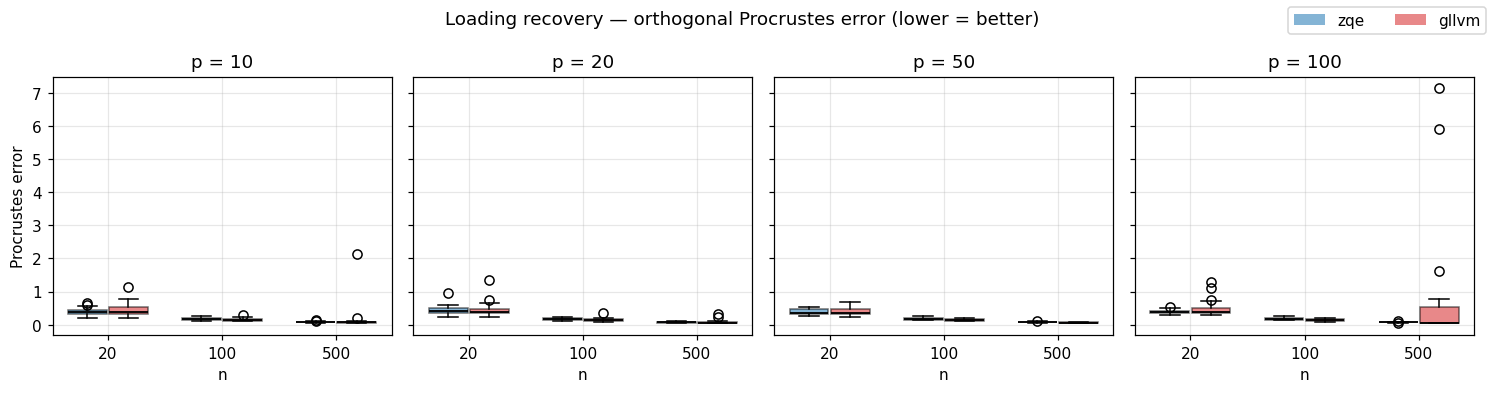

In [3]:
def grouped_box(ax, sub, value, p):
    """Side-by-side method boxplots vs n, for one p panel."""
    width, offs = 0.34, {"zqe": -0.18, "gllvm": +0.18}
    xticks = np.arange(len(N_VALS))
    for m in METHODS:
        data = [sub[(sub.n == n) & (sub.method == m)][value].dropna().values
                for n in N_VALS]
        pos = xticks + offs[m]
        bp = ax.boxplot(data, positions=pos, widths=width, patch_artist=True,
                        manage_ticks=False, showfliers=True)
        for box in bp["boxes"]:
            box.set(facecolor=MCOLOR[m], alpha=0.55)
        for med in bp["medians"]:
            med.set(color="black", lw=1.2)
    ax.set_xticks(xticks); ax.set_xticklabels(N_VALS)
    ax.set_title(f"p = {p}"); ax.set_xlabel("n")

fig, axes = plt.subplots(1, len(P_VALS), figsize=(3.4 * len(P_VALS), 3.6),
                         sharey=True)
for ax, p in zip(np.atleast_1d(axes), P_VALS):
    grouped_box(ax, ok[ok.p == p], "procrustes", p)
axes[0].set_ylabel("Procrustes error")
handles = [plt.Rectangle((0, 0), 1, 1, fc=MCOLOR[m], alpha=0.55) for m in METHODS]
fig.legend(handles, METHODS, loc="upper right", ncol=2)
fig.suptitle("Loading recovery — orthogonal Procrustes error (lower = better)")
fig.tight_layout(); plt.show()

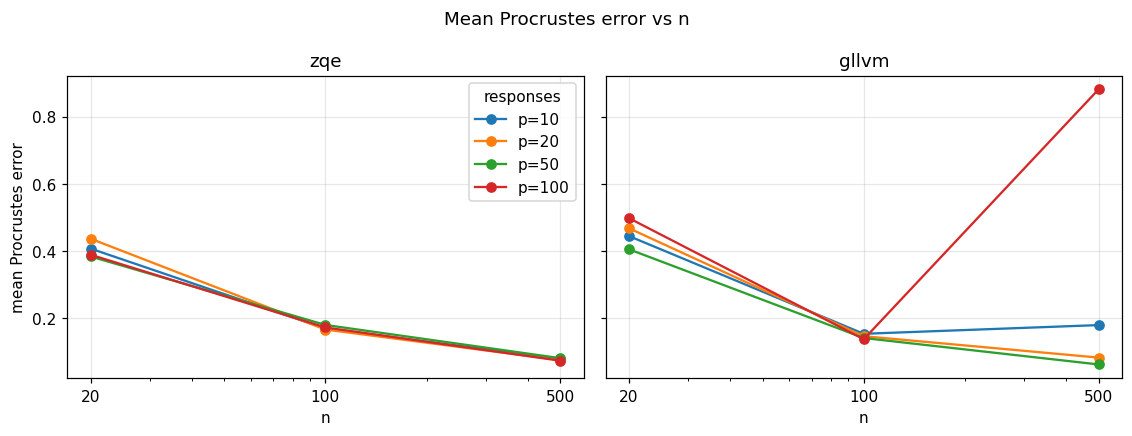

In [4]:
# Mean Procrustes vs n, lines per p (one panel per method)
fig, axes = plt.subplots(1, len(METHODS), figsize=(5.2 * len(METHODS), 4),
                         sharey=True)
mean_p = ok.groupby(["method", "p", "n"]).procrustes.mean().reset_index()
for ax, m in zip(np.atleast_1d(axes), METHODS):
    for p in P_VALS:
        s = mean_p[(mean_p.method == m) & (mean_p.p == p)].sort_values("n")
        ax.plot(s.n, s.procrustes, "o-", label=f"p={p}")
    ax.set_xscale("log"); ax.set_xticks(N_VALS); ax.set_xticklabels(N_VALS)
    ax.set_title(m); ax.set_xlabel("n")
axes[0].set_ylabel("mean Procrustes error"); axes[0].legend(title="responses")
fig.suptitle("Mean Procrustes error vs n"); fig.tight_layout(); plt.show()

## 1b · Tail risk & worst-case — the reliability story

The means above flatter neither method: the real difference is in the **spread
and the tail**. A (variational) MLE like gllvm is asymptotically efficient under
correct specification, so it tends to win the **median** by a hair — but it pays
with a **fat tail of catastrophic fits** (Procrustes ≫ 1, i.e. completely wrong),
especially when information is scarce. ZQE trades a sliver of median accuracy for
far lower variance and essentially no blow-ups.

Below: median (typical fit), 90th percentile, worst-case max, and the rate of
catastrophic fits (Procrustes > 0.5).

median           p90         worst           std        catastrophe  \
method   gllvm    zqe  gllvm    zqe  gllvm    zqe  gllvm    zqe       gllvm   
p   n                                                                         
10  20   0.377  0.394  0.672  0.574  1.142  0.650  0.227  0.112       0.300   
    100  0.142  0.166  0.229  0.211  0.304  0.250  0.054  0.035       0.000   
    500  0.069  0.074  0.120  0.112  2.128  0.126  0.460  0.021       0.050   
20  20   0.393  0.417  0.656  0.537  1.336  0.955  0.243  0.156       0.250   
    100  0.135  0.159  0.188  0.212  0.344  0.233  0.057  0.036       0.000   
    500  0.057  0.071  0.113  0.098  0.318  0.110  0.069  0.016       0.000   
50  20   0.344  0.356  0.661  0.505  0.689  0.521  0.142  0.082       0.211   
    100  0.140  0.175  0.171  0.215  0.195  0.254  0.025  0.033       0.000   
    500  0.059  0.079  0.088  0.093  0.090  0.114  0.016  0.012       0.000   
100 20   0.374  0.378  0.786  0.496  1.281  0.534  0.270  0.063       0.250   
    100  0.135  0.165  0.184  0.206  0.213  0.254  0.035  0.035       0.000   
    500  0.059  0.072  2.053  0.084  7.134  0.102  1.976  0.011       0.250   

               
method    zqe  
p   n          
10  20   0.20  
    100  0.00  
    500  0.00  
20  20   0.25  
    100  0.00  
    500  0.00  
50  20   0.15  
    100  0.00  
    500  0.00  
100 20   0.05  
    100  0.00  
    500  0.00

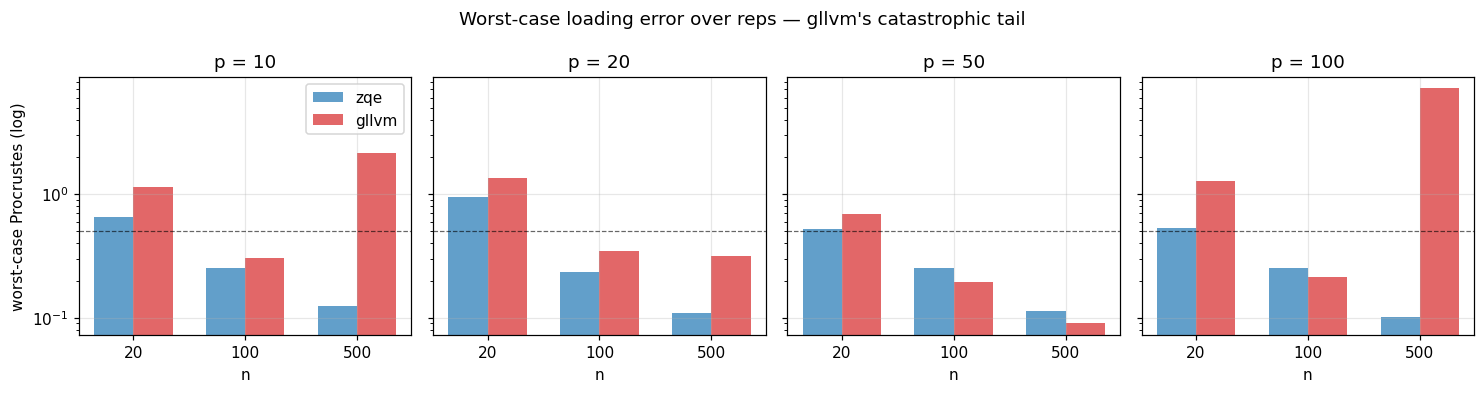

In [5]:
tail = (ok.groupby(["p", "n", "method"]).procrustes
        .agg(median="median", p90=lambda s: s.quantile(0.90),
             worst="max", std="std",
             catastrophe=lambda s: float((s > 0.5).mean()))
        .round(3))
display(tail.unstack("method"))

# worst-case Procrustes across the sweep (note the log y-axis)
fig, axes = plt.subplots(1, len(P_VALS), figsize=(3.4 * len(P_VALS), 3.6),
                         sharey=True)
worst = ok.groupby(["p", "n", "method"]).procrustes.max().reset_index()
for ax, p in zip(np.atleast_1d(axes), P_VALS):
    xt = np.arange(len(N_VALS))
    for k, m in enumerate(METHODS):
        s = worst[(worst.p == p) & (worst.method == m)].set_index("n").reindex(N_VALS)
        ax.bar(xt + (k - 0.5) * 0.35, s.procrustes.values, width=0.35,
               color=MCOLOR[m], alpha=0.7, label=m)
    ax.axhline(0.5, color="k", lw=0.8, ls="--", alpha=0.6)
    ax.set_yscale("log"); ax.set_xticks(xt); ax.set_xticklabels(N_VALS)
    ax.set_title(f"p = {p}"); ax.set_xlabel("n")
axes[0].set_ylabel("worst-case Procrustes (log)"); axes[0].legend()
fig.suptitle("Worst-case loading error over reps — gllvm's catastrophic tail")
fig.tight_layout(); plt.show()

## 2 · Bias & variance of parameter recovery

Join each estimate to its rep's true value and form the **residual**
$r = \hat\theta - \theta$ (per element, after Procrustes rotation for loadings).
Pooling residuals over all elements and reps of a setting:

- **bias** $= \overline{r}$ (systematic over/under-estimation; $\approx 0$ is good),
- **variance / std** $= \mathrm{sd}(r)$ (estimator noise),
- **RMSE** $= \sqrt{\overline{r^2}}$ (combines both).

We report loadings ($W$) and intercepts ($b$) separately.

In [6]:
# residual = estimate - true, matched on (p,n,rep,param,i,j)
truth = (df[df.method == "true"]
         [["p", "n", "rep", "param", "i", "j", "value"]]
         .rename(columns={"value": "true"}))
est = df[df.method.isin(METHODS) & (df.failed == 0.0)]
res = est.merge(truth, on=["p", "n", "rep", "param", "i", "j"], how="left")
res["resid"] = res["value"] - res["true"]

bv = (res.groupby(["param", "p", "n", "method"])
      .agg(bias=("resid", "mean"),
           std=("resid", "std"),
           rmse=("resid", lambda r: float(np.sqrt(np.mean(r**2)))))
      .round(4).reset_index())
print("Loadings (param='W'):")
display(bv[bv.param == "W"].pivot_table(index=["p", "n"], columns="method",
                                        values=["bias", "std", "rmse"]))

Loadings (param='W'):


bias            rmse             std        
method    gllvm     zqe   gllvm     zqe   gllvm     zqe
p   n                                                  
10  20  -0.0273 -0.0255  0.4766  0.3976  0.4764  0.3973
    100  0.0009 -0.0004  0.1544  0.1636  0.1546  0.1638
    500  0.0137  0.0049  0.5587  0.0779  0.5593  0.0779
20  20   0.0099  0.0500  0.5430  0.4776  0.5432  0.4753
    100  0.0028 -0.0065  0.1570  0.1727  0.1570  0.1727
    500  0.0050 -0.0029  0.1095  0.0771  0.1094  0.0771
50  20   0.0159  0.0043  0.4361  0.3958  0.4359  0.3959
    100  0.0020 -0.0038  0.1435  0.1824  0.1435  0.1824
    500  0.0025  0.0016  0.0654  0.0832  0.0654  0.0832
100 20  -0.0076 -0.0152  0.5665  0.3933  0.5665  0.3930
    100  0.0014 -0.0052  0.1416  0.1756  0.1417  0.1755
    500  0.0912  0.0004  2.1606  0.0747  2.1589  0.0747

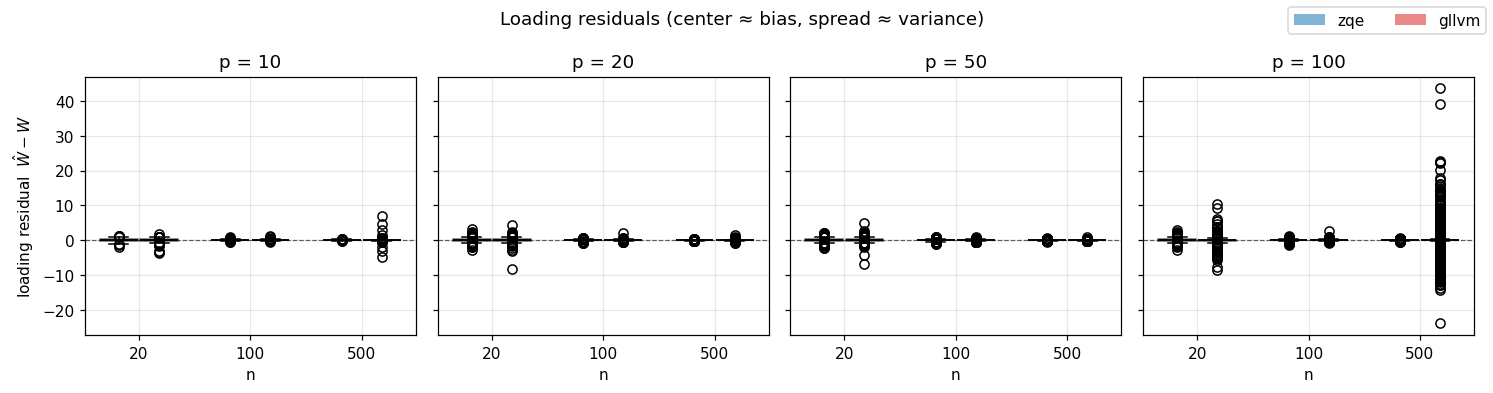

In [7]:
# Residual boxplots for loadings: center offset = bias, spread = variance.
fig, axes = plt.subplots(1, len(P_VALS), figsize=(3.4 * len(P_VALS), 3.6),
                         sharey=True)
W_res = res[res.param == "W"]
for ax, p in zip(np.atleast_1d(axes), P_VALS):
    width, offs = 0.34, {"zqe": -0.18, "gllvm": +0.18}
    xticks = np.arange(len(N_VALS))
    for m in METHODS:
        data = [W_res[(W_res.p == p) & (W_res.n == n) & (W_res.method == m)]
                .resid.dropna().values for n in N_VALS]
        bp = ax.boxplot(data, positions=xticks + offs[m], widths=width,
                        patch_artist=True, manage_ticks=False, showfliers=True)
        for box in bp["boxes"]:
            box.set(facecolor=MCOLOR[m], alpha=0.55)
        for med in bp["medians"]:
            med.set(color="black", lw=1.2)
    ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.6)
    ax.set_xticks(xticks); ax.set_xticklabels(N_VALS)
    ax.set_title(f"p = {p}"); ax.set_xlabel("n")
axes[0].set_ylabel(r"loading residual  $\hat W - W$")
handles = [plt.Rectangle((0, 0), 1, 1, fc=MCOLOR[m], alpha=0.55) for m in METHODS]
fig.legend(handles, METHODS, loc="upper right", ncol=2)
fig.suptitle("Loading residuals (center ≈ bias, spread ≈ variance)")
fig.tight_layout(); plt.show()

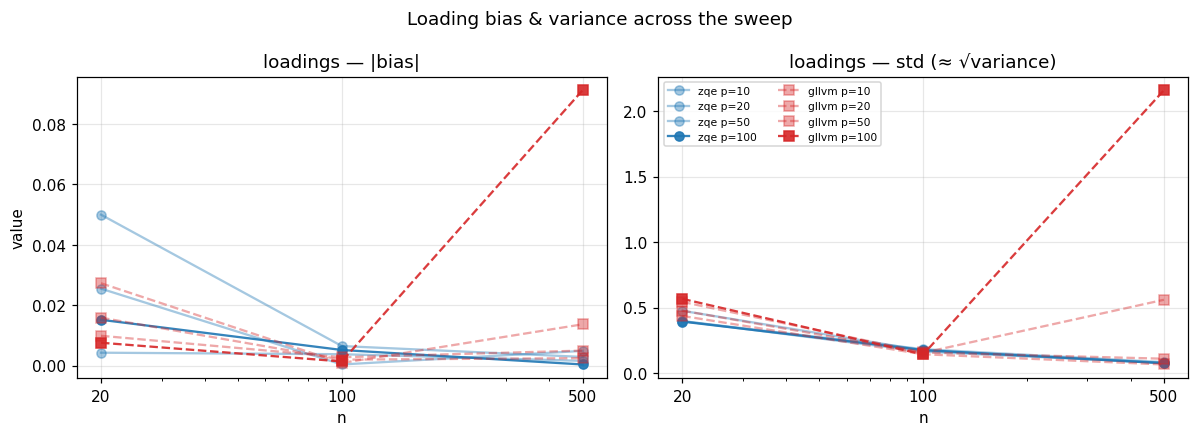

In [8]:
# |bias| and std of loadings vs n, lines per p (one panel each)
W_bv = bv[bv.param == "W"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (col, lab) in zip(axes, [("bias", "|bias|"), ("std", "std (≈ √variance)")]):
    for m in METHODS:
        for p in P_VALS:
            s = W_bv[(W_bv.method == m) & (W_bv.p == p)].sort_values("n")
            y = s[col].abs() if col == "bias" else s[col]
            ax.plot(s.n, y, "o-" if m == "zqe" else "s--",
                    color=MCOLOR[m], alpha=0.4 + 0.5 * (p == max(P_VALS)),
                    label=f"{m} p={p}")
    ax.set_xscale("log"); ax.set_xticks(N_VALS); ax.set_xticklabels(N_VALS)
    ax.set_xlabel("n"); ax.set_title(f"loadings — {lab}")
axes[0].set_ylabel("value")
axes[1].legend(fontsize=7, ncol=2)
fig.suptitle("Loading bias & variance across the sweep")
fig.tight_layout(); plt.show()

### Intercepts ($b$)

In [9]:
display(bv[bv.param == "b"].pivot_table(index=["p", "n"], columns="method",
                                       values=["bias", "std", "rmse"]))

bias            rmse             std        
method    gllvm     zqe   gllvm     zqe   gllvm     zqe
p   n                                                  
10  20  -0.1699 -0.0892  0.9238  0.6434  0.9104  0.6388
    100 -0.0137 -0.0156  0.2012  0.2238  0.2012  0.2238
    500 -0.0685 -0.0062  0.6457  0.0981  0.6437  0.0982
20  20  -0.2138 -0.1730  1.1671  0.7508  1.1488  0.7315
    100 -0.0247 -0.0325  0.2346  0.2632  0.2336  0.2615
    500  0.0011 -0.0046  0.1099  0.1027  0.1100  0.1027
50  20  -0.1717 -0.0944  1.0758  0.6183  1.0625  0.6114
    100 -0.0194 -0.0203  0.1984  0.2341  0.1975  0.2333
    500 -0.0039 -0.0060  0.0920  0.1102  0.0920  0.1101
100 20  -0.2400 -0.1355  1.4597  0.7217  1.4402  0.7090
    100 -0.0208 -0.0214  0.2356  0.2509  0.2347  0.2500
    500  0.0947 -0.0045  5.9291  0.0957  5.9298  0.0956

## 3 · Fit time

Wall-clock seconds per fit (mean over reps), log–log vs $p$, one line per $n$.

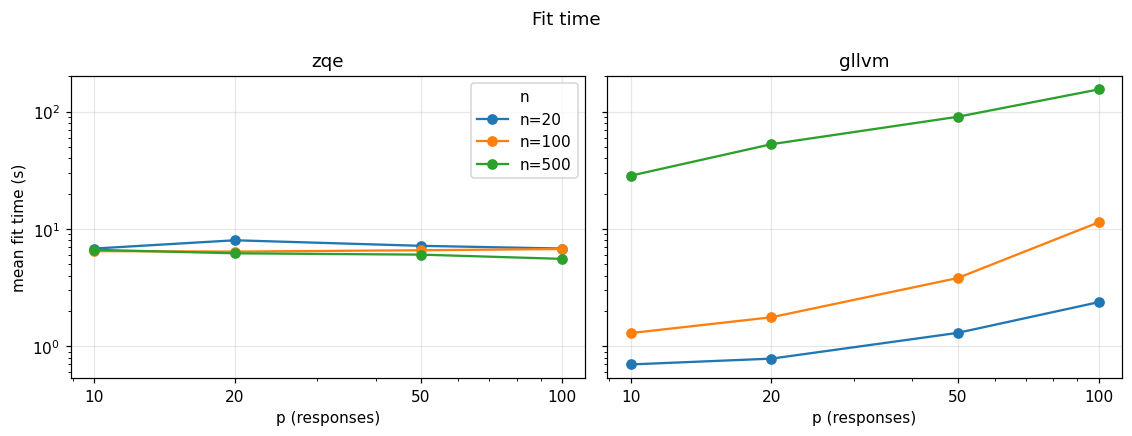

In [10]:
fig, axes = plt.subplots(1, len(METHODS), figsize=(5.2 * len(METHODS), 4),
                         sharey=True)
mean_t = ok.groupby(["method", "p", "n"]).time_sec.mean().reset_index()
for ax, m in zip(np.atleast_1d(axes), METHODS):
    for n in N_VALS:
        s = mean_t[(mean_t.method == m) & (mean_t.n == n)].sort_values("p")
        ax.plot(s.p, s.time_sec, "o-", label=f"n={n}")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xticks(P_VALS); ax.set_xticklabels(P_VALS)
    ax.set_title(m); ax.set_xlabel("p (responses)")
axes[0].set_ylabel("mean fit time (s)"); axes[0].legend(title="n")
fig.suptitle("Fit time"); fig.tight_layout(); plt.show()

## Takeaways

Under **correct specification** the (variational) MLE is asymptotically efficient, so gllvm edges the **median** Procrustes in the comfortable regime — expected, and not a race ZQE can win. ZQE's turf is the rest of the table: **much lower variance, no catastrophic blow-ups, and a flat ~6 s fit time** vs gllvm's n-scaling cost (25×+ at n=500). The head-to-head means below, read alongside the tail-risk panel, tell that story.

In [11]:
head = (ok.groupby(["p", "n", "method"])
        .agg(procrustes=("procrustes", "mean"), time_s=("time_sec", "mean"))
        .round(3).reset_index()
        .pivot_table(index=["p", "n"], columns="method",
                     values=["procrustes", "time_s"]))
head

procrustes          time_s       
method       gllvm    zqe    gllvm    zqe
p   n                                    
10  20       0.445  0.407    0.700  6.804
    100      0.154  0.169    1.295  6.477
    500      0.180  0.079   28.455  6.644
20  20       0.468  0.437    0.784  8.011
    100      0.146  0.166    1.767  6.413
    500      0.083  0.075   52.849  6.202
50  20       0.405  0.384    1.300  7.182
    100      0.141  0.180    3.817  6.587
    500      0.062  0.081   90.525  6.042
100 20       0.498  0.389    2.376  6.810
    100      0.137  0.173   11.390  6.747
    500      0.881  0.074  154.883  5.560